In [1]:
from mEncoder import data_dir

In [2]:
data_dir

PosixPath('/home/ff72/mechanismEncoder/data')

In [11]:
DATA = 'dream_cytof'
MODEL = 'EGFR_MAPK'
csv = data_dir / f'{DATA}__{MODEL}__measurements.tsv'

In [15]:
import pandas as pd
df = pd.read_csv(csv, sep='\t', index_col=0)

In [16]:
df

,observableId,preequilibrationConditionId,time,measurement,noiseParameters,simulationConditionId,observableParameters
0,CyclinB,c184A1,0.0,1.906758,0.903754,c184A1__EGF,CyclinB_scale;CyclinB_offset
1,CyclinB,c184A1,0.0,1.893003,0.747821,c184A1__EGF,CyclinB_scale;CyclinB_offset
2,CyclinB,c184A1,5.5,2.002467,1.046653,c184A1__EGF,CyclinB_scale;CyclinB_offset
3,CyclinB,c184A1,7.0,1.799739,0.706151,c184A1__EGF,CyclinB_scale;CyclinB_offset
4,CyclinB,c184A1,9.0,2.132227,1.078130,c184A1__EGF,CyclinB_scale;CyclinB_offset
...,...,...,...,...,...,...,...
1637986,ENPP4,cZR75B,0.0,-0.158356,NaN,cZR75B,ENPP4_scale;ENPP4_offset
1637987,ZHX2,cZR75B,0.0,-1.548259,NaN,cZR75B,ZHX2_scale;ZHX2_offset
1637988,MORC2,cZR75B,0.0,-0.255642,NaN,cZR75B,MORC2_scale;MORC2_offset
1637989,IVNS1ABP,cZR75B,0.0,0.218527,NaN,cZR75B,IVNS1ABP_scale;IVNS1ABP_offset


In [28]:
import petab
df_initial = df[
    (df[petab.TIME]==0) & 
    df[petab.SIMULATION_CONDITION_ID].apply(lambda x: x.endswith('__EGF')) & 
    df[petab.OBSERVABLE_ID].apply(lambda x: x.startswith('p') and x.endswith('_obs'))
]
df_initial

,observableId,preequilibrationConditionId,time,measurement,noiseParameters,simulationConditionId,observableParameters
25524,pERK_Y204_obs,c184A1,0.0,2.613910,0.865540,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset;INPUT...
25525,pERK_Y204_obs,c184A1,0.0,2.606986,0.853603,c184A1__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset;INPUT...
25570,pERK_Y204_obs,cBT20,0.0,3.502449,0.779183,cBT20__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset;INPUT...
25571,pERK_Y204_obs,cBT20,0.0,4.108437,0.602306,cBT20__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset;INPUT...
25613,pERK_Y204_obs,cBT474,0.0,3.311345,0.762587,cBT474__EGF,pERK_Y204_obs_scale;pERK_Y204_obs_offset;INPUT...
...,...,...,...,...,...,...,...
78562,pRPS6KA1_S380_obs,cUACC812,0.0,3.272120,1.045855,cUACC812__EGF,pRPS6KA1_S380_obs_scale;pRPS6KA1_S380_obs_offs...
78607,pRPS6KA1_S380_obs,cUACC893,0.0,2.051058,0.956951,cUACC893__EGF,pRPS6KA1_S380_obs_scale;pRPS6KA1_S380_obs_offs...
78608,pRPS6KA1_S380_obs,cUACC893,0.0,1.983337,0.917768,cUACC893__EGF,pRPS6KA1_S380_obs_scale;pRPS6KA1_S380_obs_offs...
78653,pRPS6KA1_S380_obs,cZR7530,0.0,4.086669,0.914332,cZR7530__EGF,pRPS6KA1_S380_obs_scale;pRPS6KA1_S380_obs_offs...


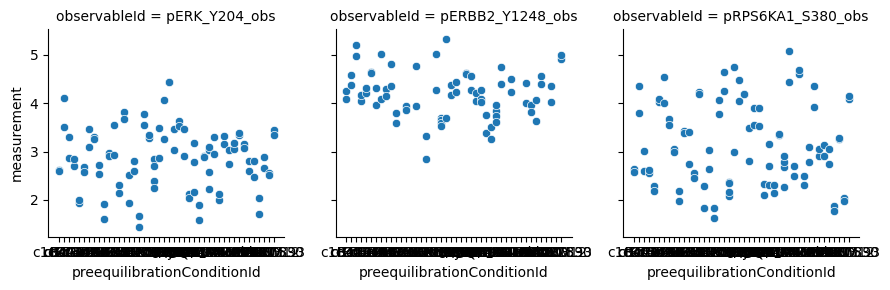

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
g = sns.FacetGrid(data=df_initial, col=petab.OBSERVABLE_ID)
g.map_dataframe(sns.scatterplot,x=petab.PREEQUILIBRATION_CONDITION_ID, y=petab.MEASUREMENT)
plt.tight_layout()

In [61]:
meas = df_initial.groupby(
    [petab.PREEQUILIBRATION_CONDITION_ID, petab.OBSERVABLE_ID]
).mean().drop(columns=[petab.TIME, petab.NOISE_PARAMETERS]).unstack().dropna().droplevel(0, axis=1)

In [62]:
meas.values

array([[4.16605593, 2.61044819, 2.60785743],
       [4.47580564, 3.80544306, 4.06862725],
       [5.08638261, 3.0899312 , 2.8047033 ],
       [4.11477857, 2.77472962, 2.59047645],
       [4.26660797, 1.96975494, 2.23863553],
       [4.62753532, 2.62546648, 4.06382011],
       [4.13685877, 3.29016837, 4.27593326],
       [4.55118213, 3.27669915, 3.6044142 ],
       [4.22037581, 2.62352982, 3.02660706],
       [4.58027756, 1.7617877 , 2.07584743],
       [3.68911638, 2.94591904, 3.41032815],
       [3.90449939, 2.23338734, 2.49979621],
       [4.35761073, 2.22064076, 2.0574728 ],
       [3.08265496, 1.5499855 , 1.73582754],
       [4.64329978, 3.30607036, 4.44656193],
       [3.61145149, 2.54921778, 2.24599785],
       [4.51503612, 3.17686097, 3.86882151],
       [4.26758025, 3.66281384, 4.26084254],
       [4.32890139, 4.44235287, 4.18673413],
       [4.62035535, 3.57815252, 3.7247067 ],
       [4.42111258, 3.19288941, 3.71239234],
       [4.12857708, 2.07560844, 2.22130865],
       [4.

In [63]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X = pca.fit_transform(meas.values)

<AxesSubplot:>

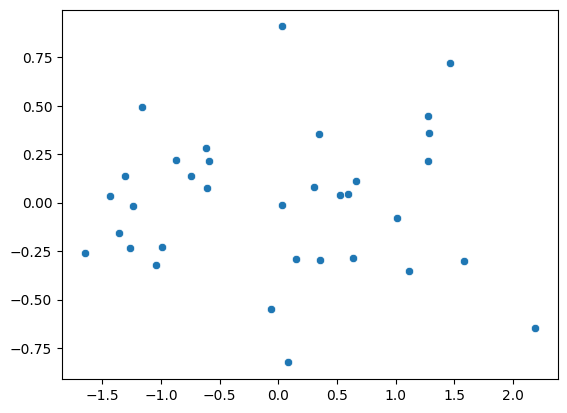

In [64]:
sns.scatterplot(x=X[:,0], y=X[:,1])

In [65]:
meas.columns

Index(['pERBB2_Y1248_obs', 'pERK_Y204_obs', 'pRPS6KA1_S380_obs'], dtype='object', name='observableId')

<AxesSubplot:ylabel='Count'>

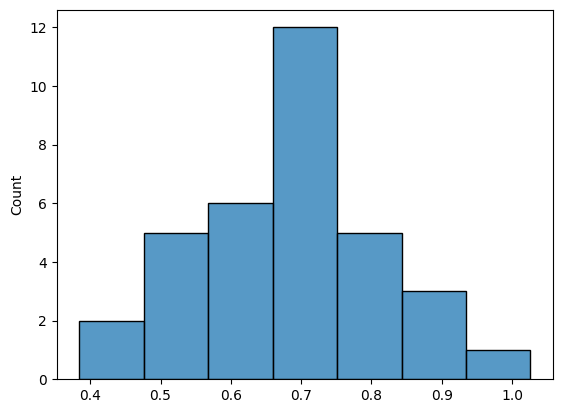

In [68]:
sns.histplot(x=meas.pERK_Y204_obs/meas.pERBB2_Y1248_obs)

<AxesSubplot:ylabel='Count'>

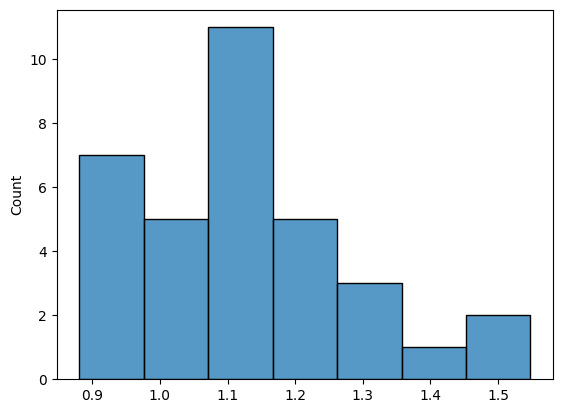

In [71]:
sns.histplot(x=meas.pRPS6KA1_S380_obs/meas.pERK_Y204_obs)